# Model Comparison — USGS Streamflow

Trains four spatiotemporal architectures on the Delaware River basin gauges and compares test MAE/MSE.

| Model | Temporal encoder | Spatial encoder |
|---|---|---|
| **DCRNN** | GRU | Diffusion convolution (ChebNet) |
| **GRUGCNModel** | GRU | Graph convolution (GCN) |
| **GraphWaveNet** | Dilated TCN | Adaptive adjacency GCN |
| **TransformerModel** | Self-attention | None (flat node axis) |

Settings: `window=7` days in → `horizon=3` days out, 31 gauges, daily discharge.

## 1. Data setup (reused from usgs_streamflow_tsl.ipynb)

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

# --- Target DataFrame ---
streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)

site_rename_list = [
    'site0',  'site1',  'site2',  'site3',  'site4',
    'site6',  'site7',  'site9',  'site11', 'site13',
    'site14', 'site15', 'site16', 'site17', 'site5',
    'site10', 'site12', 'site8',
    'site18', 'site19', 'site20', 'site21', 'site22',
    'site23', 'site24', 'site25', 'site26', 'site27',
    'site28', 'site29', 'site30'
]
target = streamflow.rename(columns=dict(zip(streamflow.columns, site_rename_list)))
target = target[sorted(target.columns, key=lambda x: int(x.replace('site', '')))]

# Fill any NaNs with forward-fill then back-fill
target = target.ffill().bfill()

N_NODES = target.shape[1]
print(f'Target: {target.shape}  ({target.shape[0]} timesteps, {N_NODES} nodes)')

# --- Connectivity ---
graph_edges_all = [
    ('site0','site2'),('site1','site2'),('site2','site6'),('site3','site6'),
    ('site4','site6'),('site5','site6'),('site6','site8'),('site7','site8'),
    ('site8','site9'),('site9','site11'),('site10','site11'),('site11','site13'),
    ('site12','site13'),('site13','site15'),('site14','site15'),('site15','site17'),
    ('site16','site17'),('site18','site21'),('site19','site20'),('site20','site21'),
    ('site21','site26'),('site22','site26'),('site23','site26'),('site24','site26'),
    ('site25','site26'),('site26','site27'),('site27','site30'),('site28','site29'),
    ('site29','site30'),('site30','site13'),
]
node_to_idx = {f'site{i}': i for i in range(31)}
src = [node_to_idx[u] for u, v in graph_edges_all]
dst = [node_to_idx[v] for u, v in graph_edges_all]
edge_index  = torch.tensor([src, dst], dtype=torch.long)
edge_weight = torch.ones(edge_index.shape[1], dtype=torch.float)
connectivity = (edge_index, edge_weight)

print(f'Graph: {N_NODES} nodes, {edge_index.shape[1]} edges')

Seed set to 42


Target: (365, 31)  (365 timesteps, 31 nodes)
Graph: 31 nodes, 30 edges


## 2. Shared dataset and datamodule factory

In [2]:
WINDOW  = 7
HORIZON = 3
BATCH   = 16

torch_dataset = SpatioTemporalDataset(
    target=target,
    connectivity=connectivity,
    window=WINDOW,
    horizon=HORIZON,
    stride=1,
)

def make_dm():
    """Fresh DataModule with a refitted scaler — call once per model run."""
    dm = SpatioTemporalDataModule(
        dataset=torch_dataset,
        scalers={'target': StandardScaler(axis=(0, 1))},
        splitter=TemporalSplitter(val_len=0.1, test_len=0.2),
        batch_size=BATCH,
        workers=4,
    )
    dm.setup()
    return dm

dm_check = make_dm()
batch = next(iter(dm_check.train_dataloader()))
print('Sample input x :', batch.input.x.shape)   # (B, window, N, 1)
print('Sample target y:', batch.y.shape)          # (B, horizon, N, 1)
print('Train / Val / Test batches:',
      len(dm_check.train_dataloader()),
      len(dm_check.val_dataloader()),
      len(dm_check.test_dataloader()))

Sample input x : torch.Size([16, 7, 31, 1])
Sample target y: torch.Size([16, 3, 31, 1])
Train / Val / Test batches: 15 2 5


## 3. Training helper + forecast collection

In [3]:
def train_and_evaluate(model, name, max_epochs=30):
    """
    Train model, evaluate on test set, and collect forecasts.

    Returns
    -------
    metrics : dict
        test_mae, test_mse, model name, param count
    forecasts : dict
        y_true  : (n_test, N) — step-1 of horizon, inverse-scaled (m³/s)
        y_hat   : (n_test, N) — step-1 of horizon, inverse-scaled (m³/s)
        y_true_h: (n_test, horizon, N) — full horizon, inverse-scaled
        y_hat_h : (n_test, horizon, N) — full horizon, inverse-scaled
        dates   : DatetimeIndex aligned to the first predicted day
        dm      : the fitted DataModule (scaler lives here)
    """
    print(f'\n{"="*60}')
    print(f'  {name}')
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n_params:,}')
    print(f'{"="*60}')

    dm = make_dm()

    predictor = Predictor(
        model=model,
        optim_class=torch.optim.Adam,
        optim_kwargs={'lr': 1e-3},
        loss_fn=MaskedMAE(),
        metrics={'mae': MaskedMAE(), 'mse': MaskedMSE()},
        scale_target=True,
    )

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator='auto',
        devices=1,
        enable_progress_bar=True,
        logger=False,
        enable_checkpointing=False,
    )

    trainer.fit(predictor, datamodule=dm)
    test_metrics = trainer.test(predictor, datamodule=dm, verbose=False)

    # ── Collect raw predictions on the test set ──────────────────────────
    predictor.eval()
    y_true_list, y_hat_list = [], []

    with torch.no_grad():
        for batch in dm.test_dataloader():
            y_hat = predictor.predict_batch(batch, preprocess=False, postprocess=False)
            y_true_list.append(batch.y.cpu())
            y_hat_list.append(y_hat.cpu())

    # Stack → (n_test_samples, horizon, N) — keep as Tensors for inverse_transform
    y_true_all = torch.cat(y_true_list).squeeze(-1)
    y_hat_all  = torch.cat(y_hat_list).squeeze(-1)

    # batch.y comes out of the DataModule in original (m³/s) space — no inverse_transform needed.
    # y_hat from predict_batch(postprocess=False) is in scaled space — inverse_transform it.
    scaler = dm.scalers['target']
    n, h, n_nodes = y_true_all.shape
    y_true_inv = y_true_all.numpy()
    y_hat_inv  = scaler.inverse_transform(
        y_hat_all.reshape(-1, n_nodes)).reshape(n, h, n_nodes).numpy()

    # ── Align predictions to calendar dates ──────────────────────────────
    # For sample at dataset index k, the input window covers rows k … k+WINDOW-1,
    # so the first predicted timestep is row k + WINDOW in target.
    test_indices = dm.test_dataloader().dataset.indices   # integer positions in torch_dataset
    pred_dates   = target.index[[idx + WINDOW for idx in test_indices]]

    forecasts = {
        'y_true'  : y_true_inv[:, 0, :],   # (n_test, N)
        'y_hat'   : y_hat_inv[:, 0, :],    # (n_test, N)
        'y_true_h': y_true_inv,            # (n_test, horizon, N)
        'y_hat_h' : y_hat_inv,             # (n_test, horizon, N)
        'dates'   : pred_dates,
        'dm'      : dm,
    }

    test_metrics[0]['model']    = name
    test_metrics[0]['n_params'] = n_params
    return test_metrics[0], forecasts

## 4. Model A — DCRNN
Diffusion Convolutional Recurrent Neural Network.  
GRU cells with diffusion graph convolution as the spatial mixing step. Strong baseline for directed graphs.

In [ ]:
from tsl.nn.models import DCRNNModel

dcrnn = DCRNNModel(
    input_size=1,
    output_size=1,
    horizon=HORIZON,
    hidden_size=32,
    kernel_size=2,
    n_layers=2,
    dropout=0.1,
)

results_dcrnn, forecasts_dcrnn = train_and_evaluate(dcrnn, 'DCRNN')
save_path = os.path.join(FORECASTS_DIR, 'dcrnn_forecasts.pt')
torch.save(forecasts_dcrnn, save_path)
print(f'DCRNN forecasts saved to: {save_path}')

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/network/lp9617/venvs/cee520_venv/lib/python ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn       | MaskedMAE    


  DCRNN
  Trainable parameters: 70,915


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only args ['edge_weight', 'edge_index', 'x'] are forwarded to the model (DCRNNModel).
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger con

Training: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=30` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


DCRNN forecasts saved to: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/data/forecast/dcrnn_forecasts_2.pt


: 

## 5. Model B — GRUGCNModel
GRU encoder followed by a GCN layer for spatial aggregation.  
Simpler than DCRNN — GRU and GCN are decoupled rather than interleaved.

In [ ]:
from tsl.nn.models import GRUGCNModel

grugcn = GRUGCNModel(
    input_size=1,
    hidden_size=32,
    output_size=1,
    horizon=HORIZON,
    exog_size=0,
    enc_layers=2,
    gcn_layers=2,
)

results_grugcn, forecasts_grugcn = train_and_evaluate(grugcn, 'GRUGCNModel')
save_path = os.path.join(FORECASTS_DIR, 'grugcn_forecasts.pt')
torch.save(forecasts_grugcn, save_path)
print(f'GRUGCNModel forecasts saved to: {save_path}')

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/network/lp9617/venvs/cee520_venv/lib/python ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn       | MaskedMAE    


  GRUGCNModel
  Trainable parameters: 14,019


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only args ['edge_weight', 'edge_index', 'x'] are forwarded to the model (GRUGCNModel).
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger co

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


GRUGCNModel forecasts saved to: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/data/clean/grugcn_forecasts.pt


## 6. Model C — GraphWaveNet
Dilated causal TCN with adaptive adjacency — learns a latent node embedding to construct
an additional adjacency matrix on top of the provided graph.  
Good at capturing long-range temporal dependencies via dilation.

In [4]:
from tsl.nn.models import GraphWaveNetModel

gwn = GraphWaveNetModel(
    input_size=1,
    output_size=1,
    horizon=HORIZON,
    hidden_size=32,
    ff_size=64,
    n_layers=4,
    temporal_kernel_size=2,
    learned_adjacency=True,
    n_nodes=N_NODES,
    emb_size=8,
    dropout=0.1,
    norm='none',
)

results_gwn, forecasts_gwn = train_and_evaluate(gwn, 'GraphWaveNet')
save_path = os.path.join(FORECASTS_DIR, 'gwn_forecasts.pt')
torch.save(forecasts_gwn, save_path)
print(f'GraphWaveNet forecasts saved to: {save_path}')

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/network/lp9617/venvs/cee520_venv/lib/python ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name          | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | loss_fn       | MaskedMAE  


  GraphWaveNet
  Trainable parameters: 63,283


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Only args ['x', 'edge_index', 'edge_weight'] are forwarded to the model (GraphWaveNetModel).
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no log

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


GraphWaveNet forecasts saved to: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/data/forecast/gwn_forecasts.pt


## 7. Model D — TransformerModel
Multi-head self-attention applied along the time axis independently per node.  
No explicit graph convolution — spatial interaction is implicit via shared weights.  
Useful as a graph-free baseline.

In [7]:
from tsl.nn.models import TransformerModel

transformer = TransformerModel(
    input_size=1,
    output_size=1,
    horizon=HORIZON,
    hidden_size=32,
    ff_size=64,
    n_heads=4,
    n_layers=2,
    dropout=0.1,
    axis='time',
)

results_transformer, forecasts_transformer = train_and_evaluate(transformer, 'TransformerModel')
save_path = os.path.join(FORECASTS_DIR, 'transformer_forecasts.pt')
torch.save(forecasts_transformer, save_path)
print(f'TransformerModel forecasts saved to: {save_path}')

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/network/lp9617/venvs/cee520_venv/lib/python ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | loss_fn       | MaskedMAE    


  TransformerModel
  Trainable parameters: 19,459


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Arguments ['edge_weight', 'edge_index'] are filtered out. Only args ['x'] are forwarded to the model (TransformerModel).
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('val_loss', ..., l

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mae', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_mse', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/pytorch_lightning/core/module.py:522: You called `self.log('test_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


TransformerModel forecasts saved to: /home/lp9617/workspace/CEE520/CEE520-StreamflowGraphLearning/data/forecast/transformer_forecasts.pt


## 8. Results comparison

In [4]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl
from tsl.data import SpatioTemporalDataset, SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler
from tsl.engines import Predictor
from tsl.metrics.torch import MaskedMAE, MaskedMSE

pl.seed_everything(42)

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/clean/'))
FORECASTS_DIR = os.path.abspath(os.path.join(os.getcwd(), '../../data/forecast/'))

# --- Target DataFrame ---
streamflow = pd.read_csv(
    os.path.join(DATA_DIR, 'streamflow_wy2022.csv'),
    dtype=str, parse_dates=['date'], index_col='date'
).astype(float)


# ── Load forecasts from disk ─────────────────────────────────────────────
# Use this block when restarting the kernel to skip retraining.
MODEL_FILES = {
    'DCRNN':            'dcrnn_forecasts.pt',
    'GRUGCNModel':      'grugcn_forecasts.pt',
    'GraphWaveNet':     'gwn_forecasts.pt',
    'TransformerModel': 'transformer_forecasts.pt',
}

all_forecasts = {}
all_results   = []

for name, fname in MODEL_FILES.items():
    fpath = os.path.join(FORECASTS_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Missing: {fpath} — run the training cells first')
        continue
    fc = torch.load(fpath, weights_only=False)
    all_forecasts[name] = fc
    # Recompute MAE/MSE from saved arrays (original m³/s space)
    mae = float(np.abs(fc['y_true'] - fc['y_hat']).mean())
    mse = float(((fc['y_true'] - fc['y_hat']) ** 2).mean())
    all_results.append({'model': name, 'test_mae': mae, 'test_mse': mse, 'n_params': None})
    print(f'Loaded {name}  MAE={mae:.3f} m³/s  MSE={mse:.3f}')

df_results = pd.DataFrame(all_results).set_index('model')
df_results.columns = [c.replace('test_', '') for c in df_results.columns]
print()
print(df_results[['mae', 'mse', 'n_params']].to_string())

Seed set to 42


Loaded DCRNN  MAE=1.910 m³/s  MSE=81.604
Loaded GRUGCNModel  MAE=2.163 m³/s  MSE=94.176
Loaded GraphWaveNet  MAE=2.052 m³/s  MSE=76.013
Loaded TransformerModel  MAE=1.633 m³/s  MSE=82.166

                       mae        mse n_params
model                                         
DCRNN             1.910281  81.603668     None
GRUGCNModel       2.163400  94.175507     None
GraphWaveNet      2.052013  76.013062     None
TransformerModel  1.632579  82.166100     None


/scratch/network/lp9617/venvs/cee520_venv/lib/python3.13/site-packages/torch/serialization.py:2143: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  result = unpickler.load()


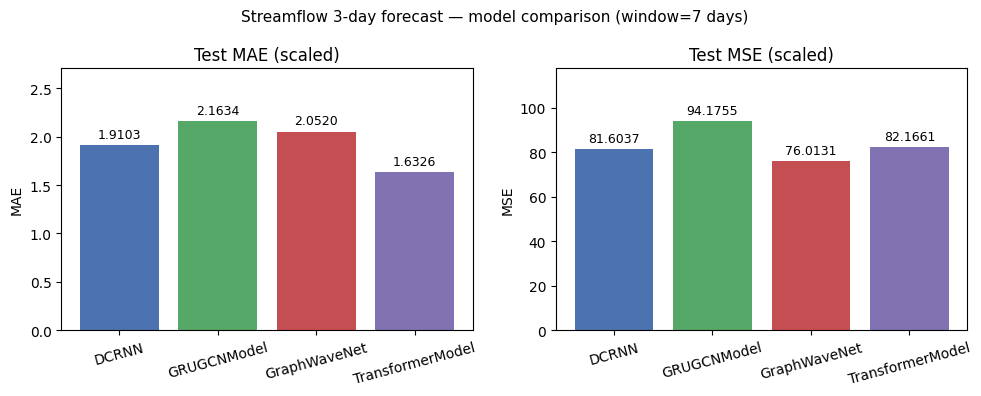

In [5]:
# ── MAE / MSE bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = df_results.index.tolist()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, ['mae', 'mse']):
    bars = ax.bar(models, df_results[metric], color=colors)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(f'Test {metric.upper()} (scaled)')
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, df_results[metric].max() * 1.25)

plt.suptitle('Streamflow 3-day forecast — model comparison (window=7 days)', fontsize=11)
plt.tight_layout()
plt.show()

## 9. All-gauge forecast plots

For each model: a grid showing all 31 gauges. Each subplot has:
- **Grey** — observed discharge in the 30 days before the test period (context)
- **Black** — observed discharge during the test period (ground truth)
- **Coloured** — model forecast (step-1 of horizon, i.e. next-day prediction)

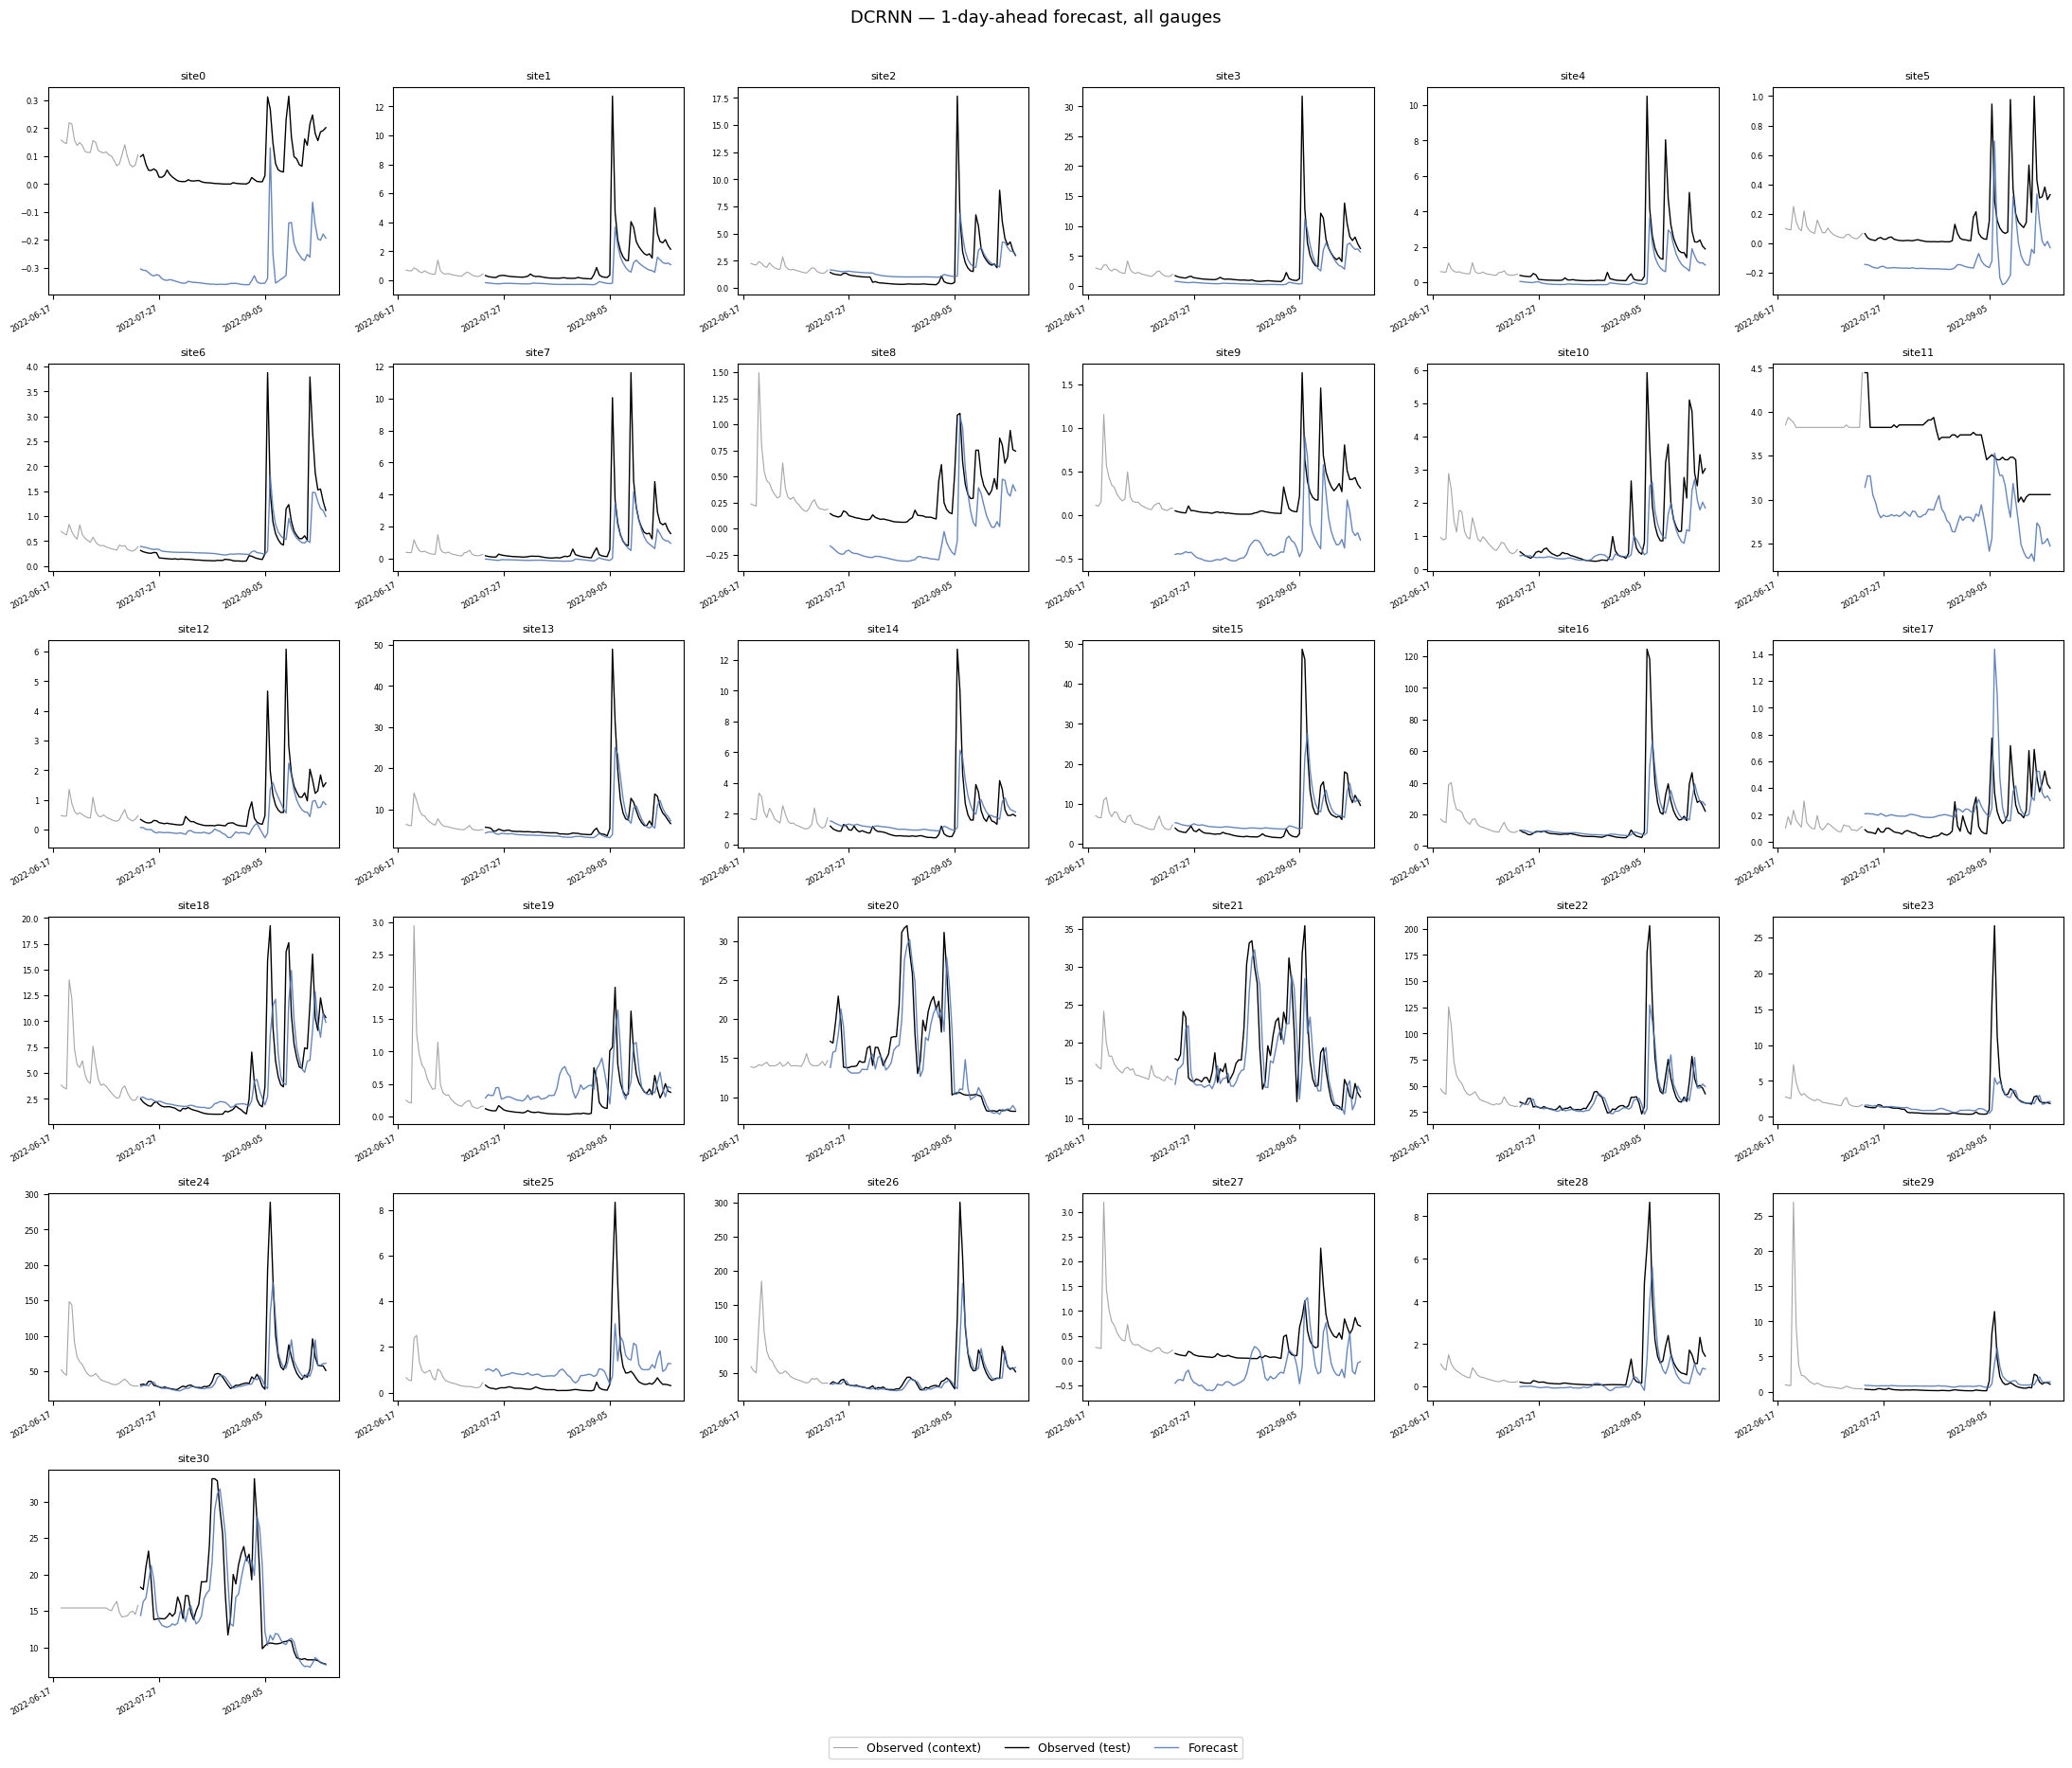

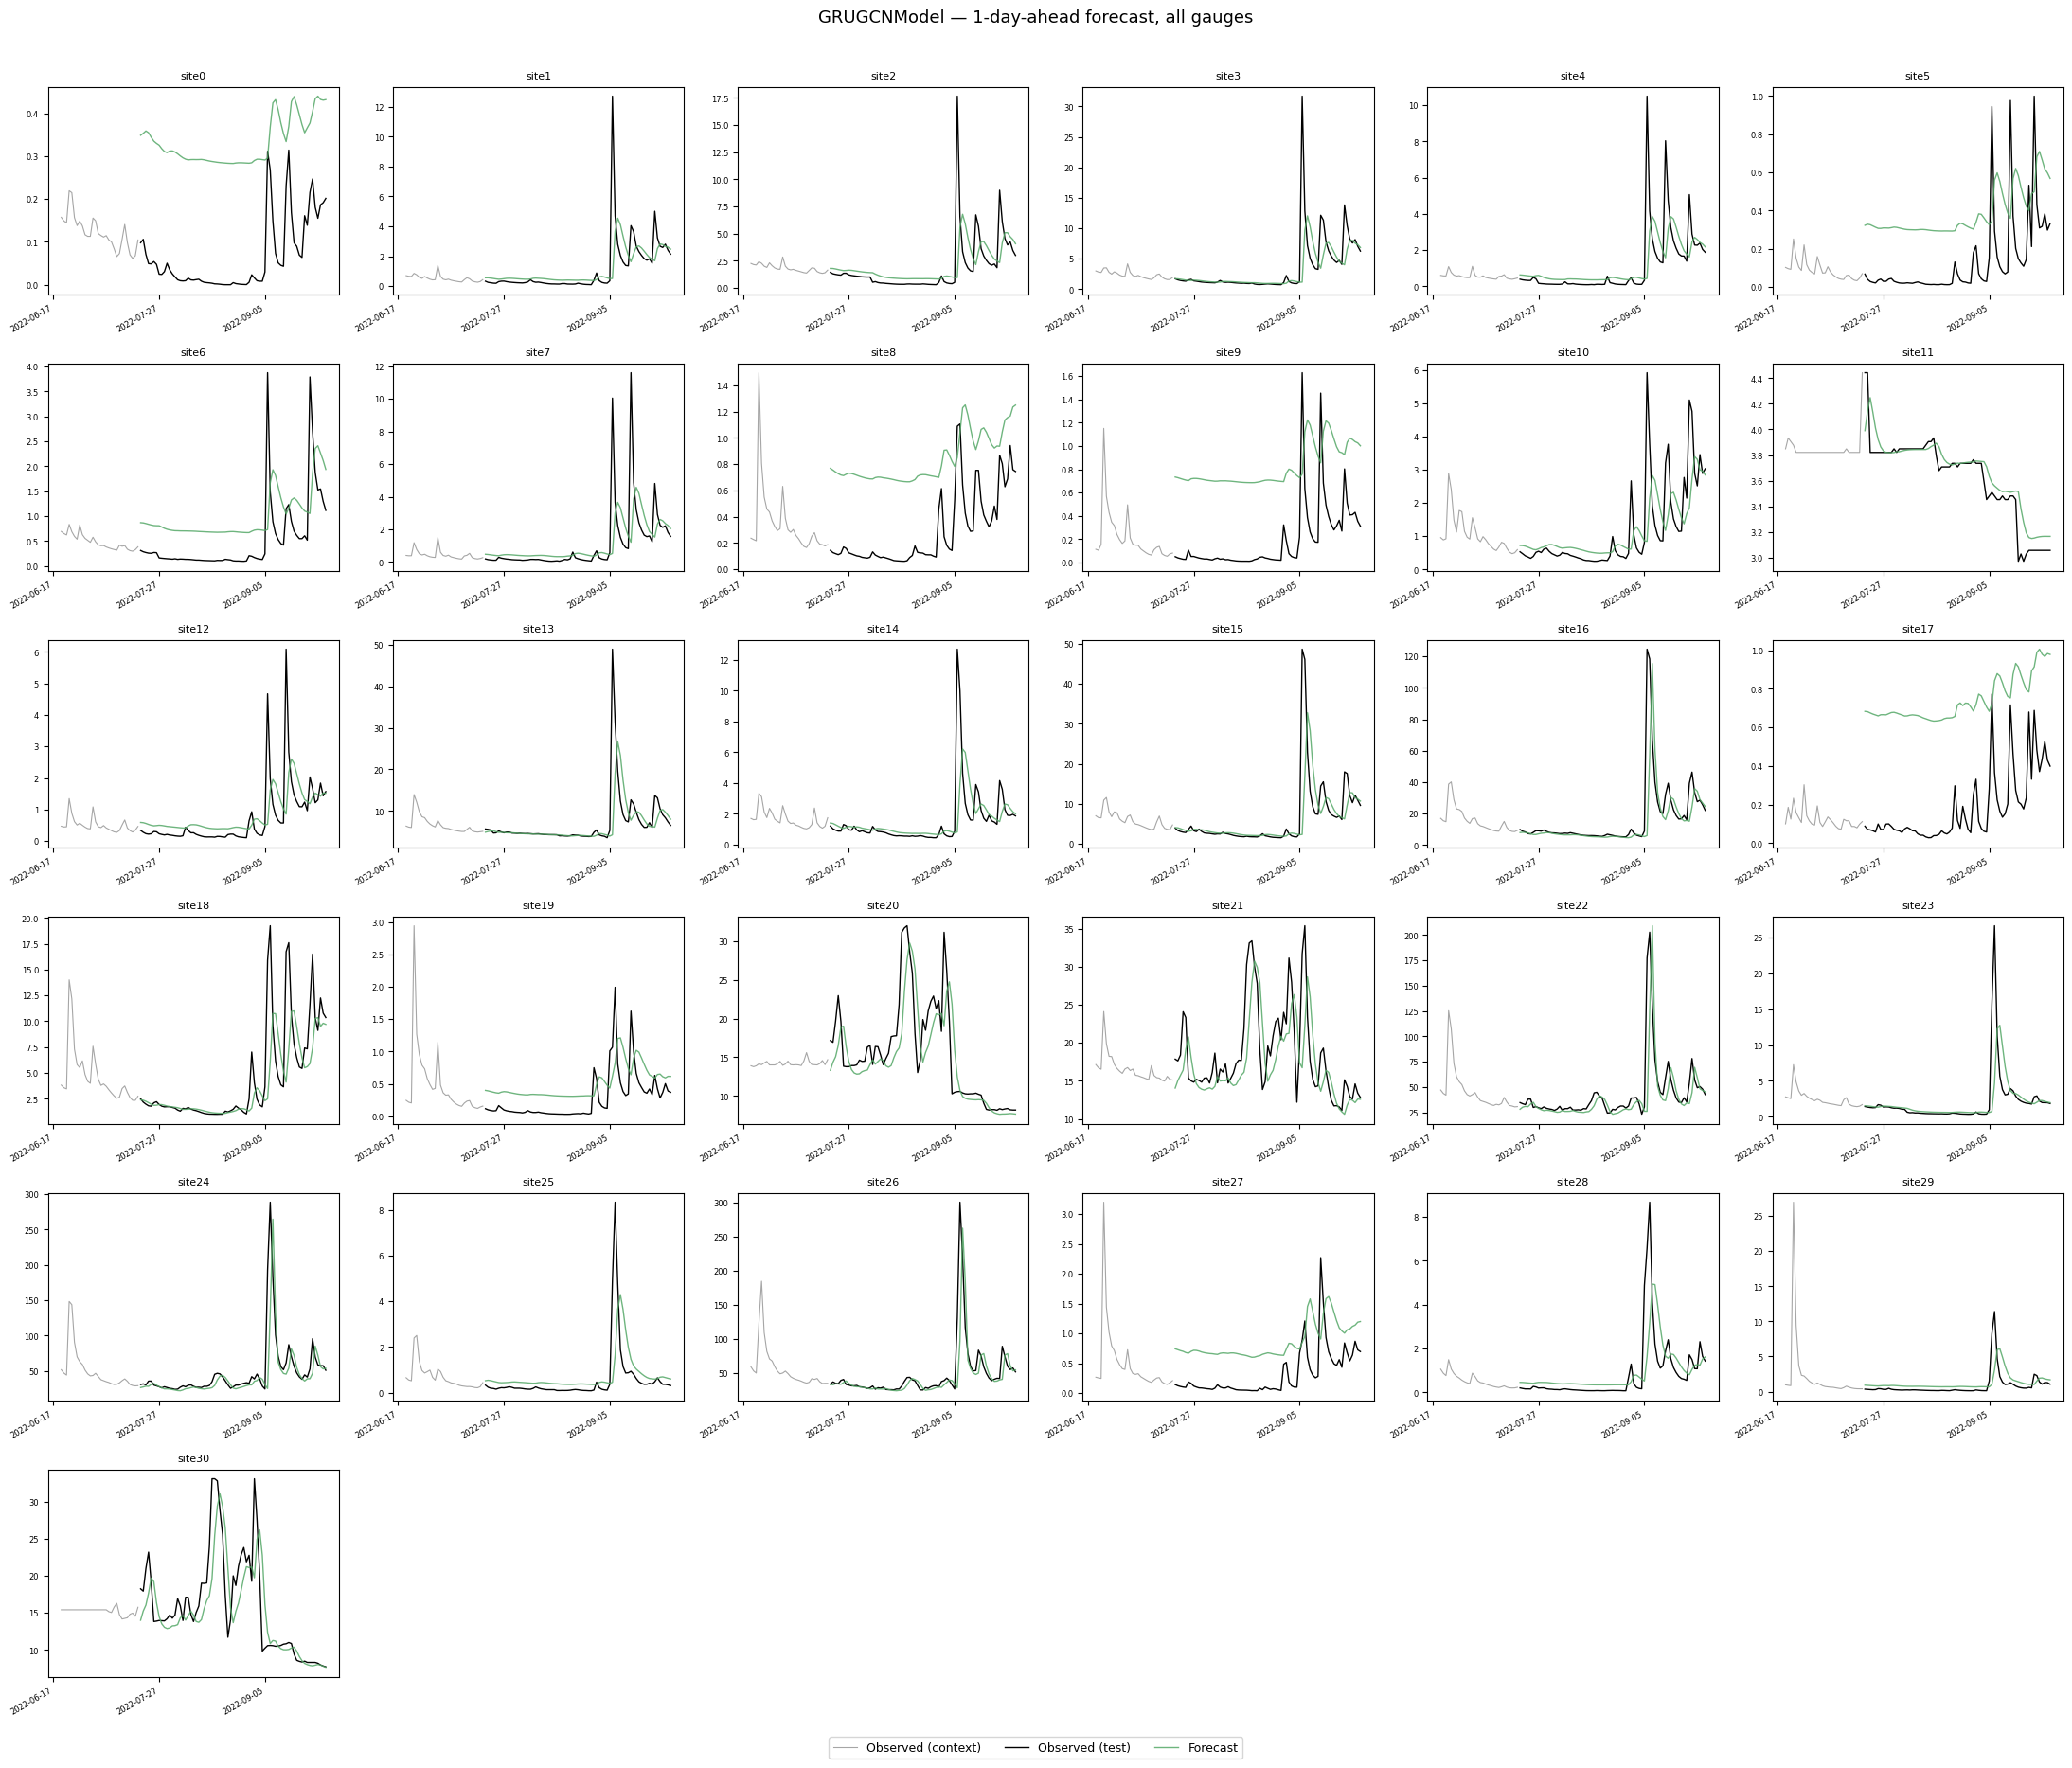

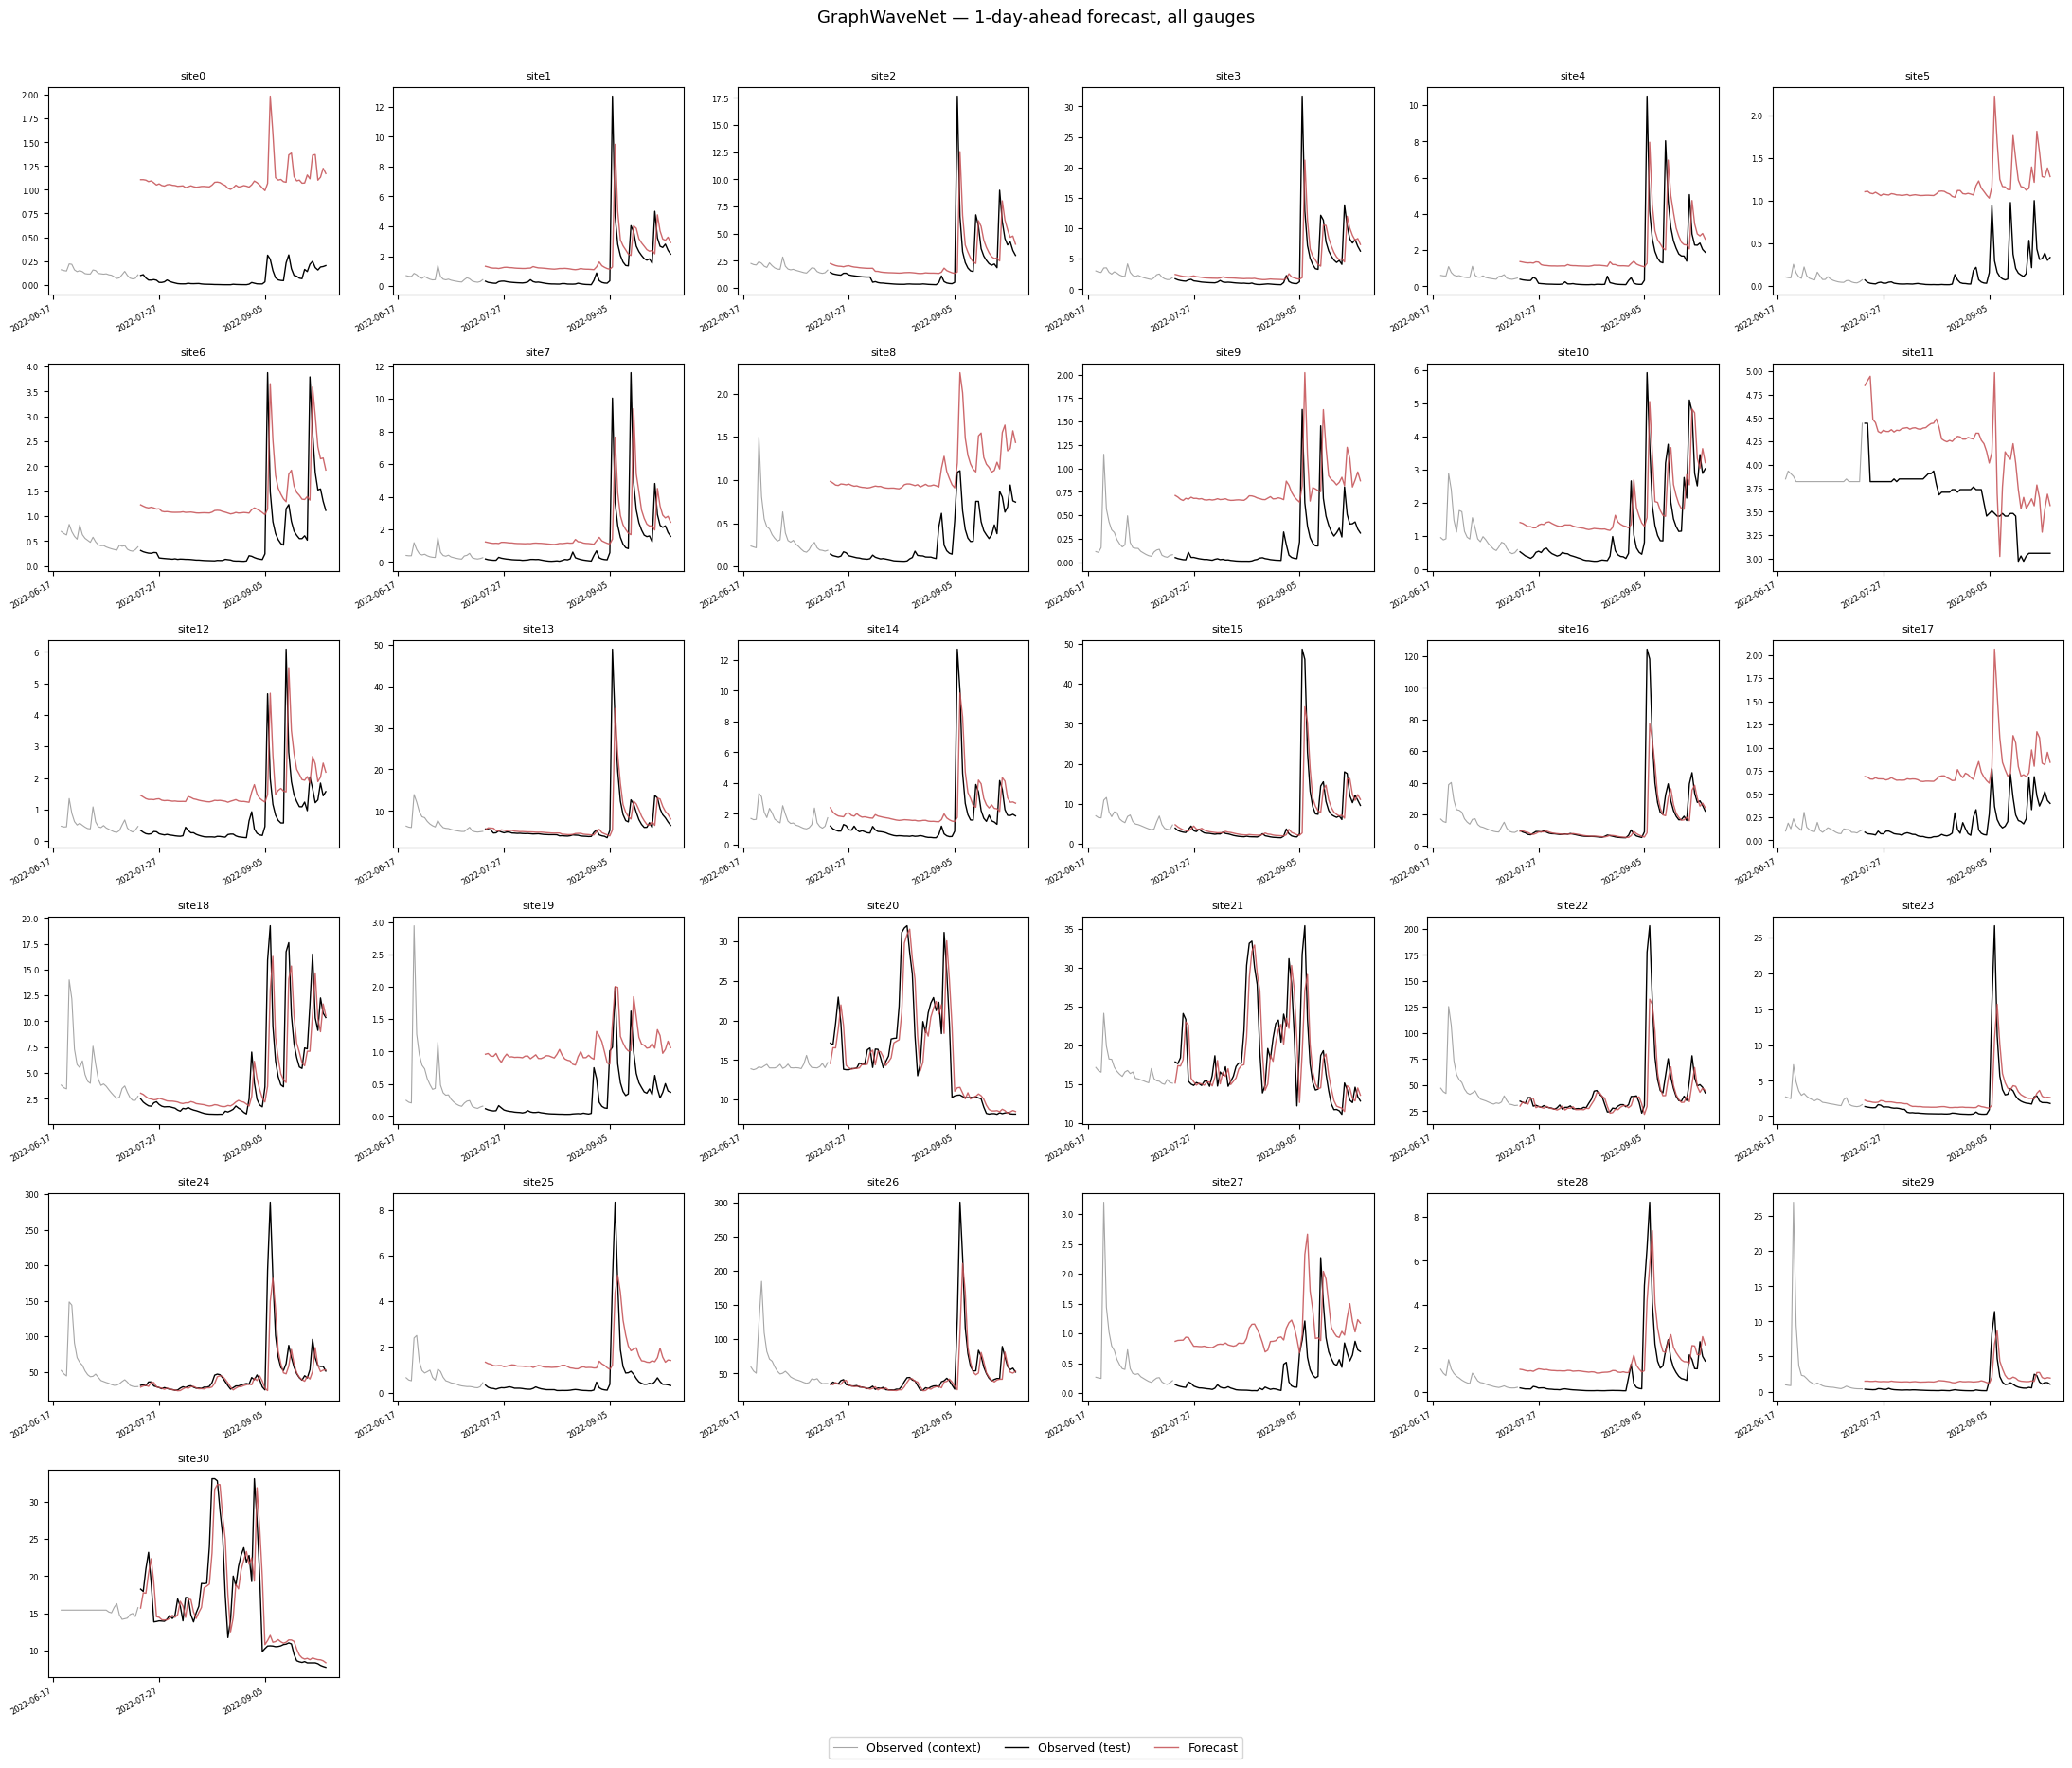

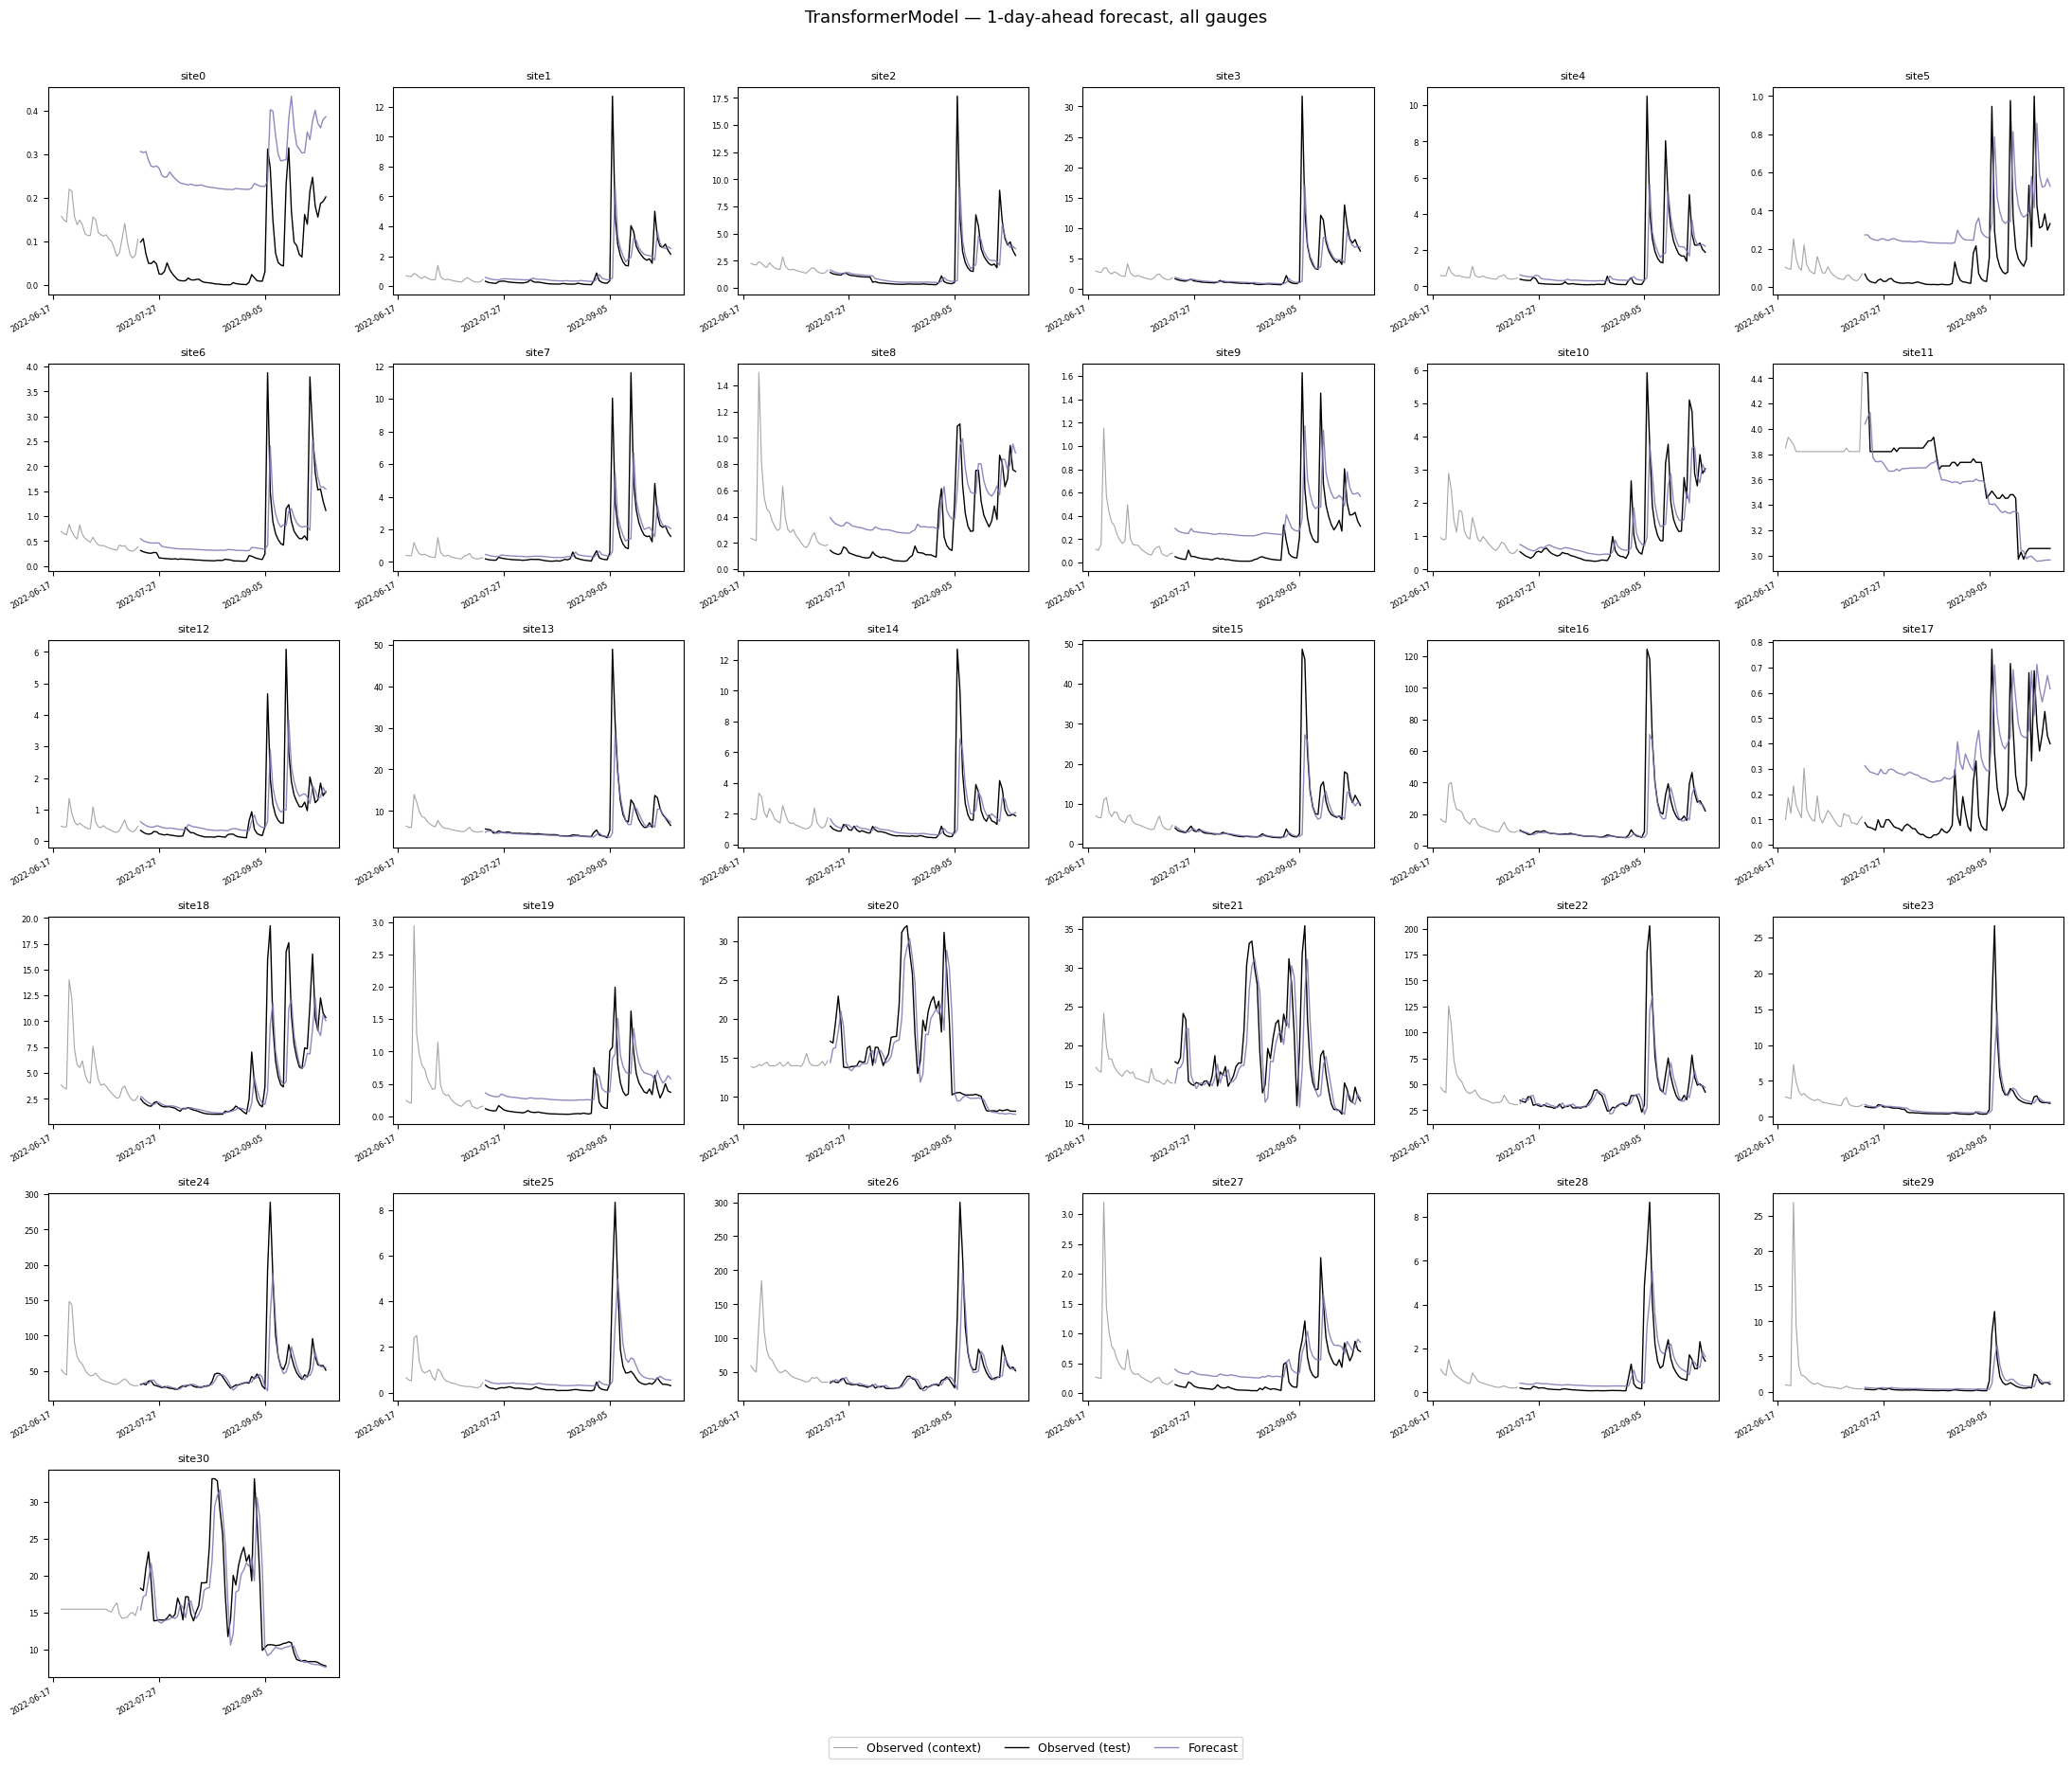

In [6]:
CONTEXT_DAYS = 30   # days of observed history to show before the test period
MODEL_COLORS = {'DCRNN': '#4C72B0', 'GRUGCNModel': '#55A868',
                'GraphWaveNet': '#C44E52', 'TransformerModel': '#8172B2'}

def plot_all_gauges(forecasts_dict, context_days=CONTEXT_DAYS):
    """
    For each model, plot all 31 gauges in a 6×6 grid.
    Shows context_days of observed history + full test period (truth vs forecast).
    """
    node_names = list(target.columns)   # site0 … site30
    ncols, nrows = 6, 6                 # 36 slots, last 5 left blank

    for model_name, fc in forecasts_dict.items():
        dates      = fc['dates']                     # DatetimeIndex, length n_test
        y_true     = fc['y_true']                    # (n_test, N)
        y_hat      = fc['y_hat']                     # (n_test, N)

        # Grab context from the target DataFrame
        test_start = dates[0]
        context_start = test_start - pd.Timedelta(days=context_days)
        context = target.loc[context_start:test_start - pd.Timedelta(days=1)]

        fig, axes = plt.subplots(nrows, ncols, figsize=(22, 18), sharex=False)
        fig.suptitle(f'{model_name} — 1-day-ahead forecast, all gauges', fontsize=13, y=1.01)

        for idx, ax in enumerate(axes.flat):
            if idx >= N_NODES:
                ax.set_visible(False)
                continue

            # Context
            ax.plot(context.index, context.iloc[:, idx],
                    color='grey', lw=0.8, alpha=0.7, label='Observed (context)')
            # Ground truth during test period
            ax.plot(dates, y_true[:, idx],
                    color='black', lw=1.0, label='Observed (test)')
            # Forecast
            ax.plot(dates, y_hat[:, idx],
                    color=MODEL_COLORS[model_name], lw=1.0, alpha=0.85, label='Forecast')

            ax.set_title(node_names[idx], fontsize=8)
            ax.tick_params(labelsize=6)
            ax.xaxis.set_major_locator(plt.MaxNLocator(3))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

        # Shared legend from the last visible axis
        handles, labels = axes.flat[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3,
                   fontsize=9, bbox_to_anchor=(0.5, -0.02))
        plt.tight_layout()
        plt.show()

plot_all_gauges(all_forecasts)

## 10. Outlet gauge — all models overlaid

site17 (`WEST BRANCH DELAWARE RIVER AT HOBART NY`) is the terminal node of the network
(no outgoing edges). This plot overlays all four model forecasts against the observed record,
with a longer context window to show seasonal patterns.

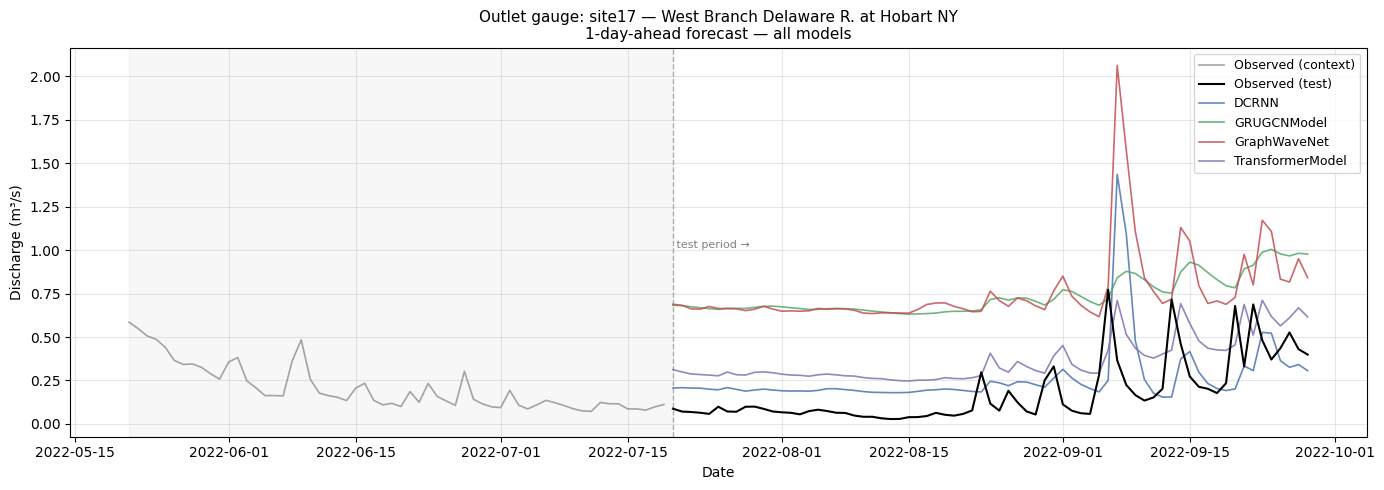

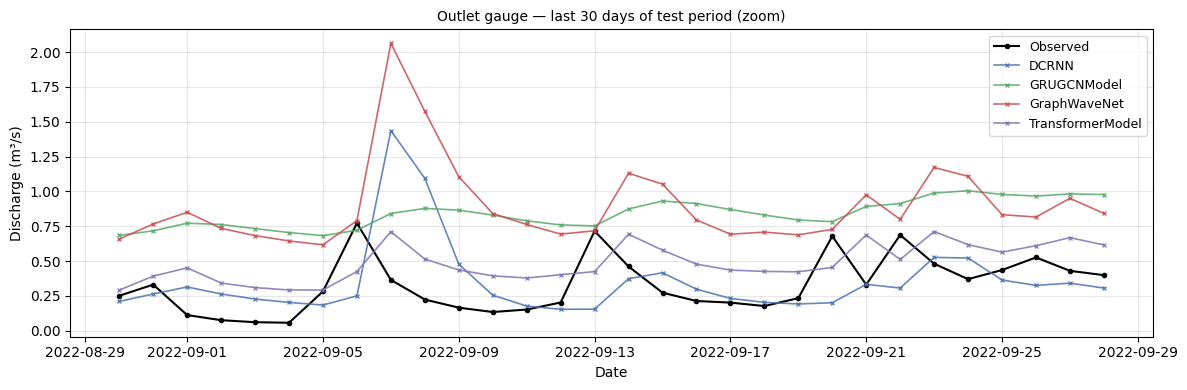

In [7]:
OUTLET_NODE  = 17          # site17 — terminal node (no outgoing edges)
OUTLET_NAME  = 'site17 — West Branch Delaware R. at Hobart NY'
CONTEXT_DAYS_OUTLET = 60   # longer window for the outlet plot

def plot_outlet(forecasts_dict, node_idx=OUTLET_NODE, context_days=CONTEXT_DAYS_OUTLET):
    """
    Single-panel plot of the outlet gauge: all models overlaid.
    Shows context_days of observed history + full test period.
    """
    # Use the first forecast dict to get dates (all models share the same test split)
    first_fc   = next(iter(forecasts_dict.values()))
    dates      = first_fc['dates']
    test_start = dates[0]

    context_start = test_start - pd.Timedelta(days=context_days)
    context = target.loc[context_start:test_start - pd.Timedelta(days=1), f'site{node_idx}']

    fig, ax = plt.subplots(figsize=(14, 5))

    # Shade the context vs test regions
    ax.axvspan(context.index[0], test_start, alpha=0.06, color='grey', label='_context region')
    ax.axvline(test_start, color='grey', lw=1, ls='--', alpha=0.6)
    ax.text(test_start, ax.get_ylim()[1] if ax.get_ylim()[1] != 1 else 1,
            ' test period →', fontsize=8, color='grey', va='bottom')

    # Observed — context
    ax.plot(context.index, context.values,
            color='grey', lw=1.2, alpha=0.7, label='Observed (context)')

    # Observed — test period (from first forecast dict)
    ax.plot(dates, first_fc['y_true'][:, node_idx],
            color='black', lw=1.5, label='Observed (test)', zorder=5)

    # Each model forecast
    for model_name, fc in forecasts_dict.items():
        ax.plot(dates, fc['y_hat'][:, node_idx],
                color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85,
                label=f'{model_name}')

    ax.set_title(f'Outlet gauge: {OUTLET_NAME}\n1-day-ahead forecast — all models', fontsize=11)
    ax.set_ylabel('Discharge (m³/s)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Zoom: last 30 days of test period ────────────────────────────────
    zoom_start = dates[-30]
    mask = dates >= zoom_start

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(dates[mask], first_fc['y_true'][mask, node_idx],
             color='black', lw=1.5, marker='o', ms=3, label='Observed')

    for model_name, fc in forecasts_dict.items():
        ax2.plot(dates[mask], fc['y_hat'][mask, node_idx],
                 color=MODEL_COLORS[model_name], lw=1.2, alpha=0.85,
                 marker='x', ms=3, label=model_name)

    ax2.set_title(f'Outlet gauge — last 30 days of test period (zoom)', fontsize=10)
    ax2.set_ylabel('Discharge (m³/s)')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_outlet(all_forecasts)

---
## To-Do

- [ ] **Fix prediction magnitude** — forecasted discharge is significantly off from observed values. Possible causes to investigate:
  - Verify `inverse_transform` is using the correct scaler (confirm `scaler.scale` and `scaler.bias` match what was fit on the training set)
  - Check whether `batch.y` is already inverse-scaled by the time we collect it, meaning we may be double-transforming the ground truth
  - Confirm `postprocess=False` in `predict_batch` leaves the model output in the same scaled space as `batch.y` — if the model predicts in unscaled space, we would be inverse-transforming twice
  - Print raw scaled values of `batch.y` vs `y_hat` before inverse-transform to verify they are on the same scale

- [ ] **Increase training epochs** — 30 epochs may be insufficient; plot train/val loss curves to check for underfitting

- [ ] **Tune hyperparameters** — hidden size, number of layers, learning rate, dropout for each model

- [ ] **Add precipitation as a covariate** — pass `precipitation_wy2022.csv` as an exogenous input (`exog_size=1`) to all models that support it

- [ ] **Evaluate per-gauge performance** — compute MAE/MSE individually for each of the 31 gauges to identify where models struggle most (e.g. reservoir-influenced gauges like site8, site26)

- [ ] **Save trained models** — add `ModelCheckpoint` callback to save best val-loss weights for each model